In [21]:
import os
from pathlib import Path

import yaml
import pandas as pd

log_root = Path("logs/thinker")

# 분석할 폴더 이름을 여기 리스트에 넣으세요.
# 비워두면(log_root 아래 모든 폴더를 사용)
target_run_names = [
    "thinker-20251204-213652",
    "spaceinvaders_actor2.5M_model8M",
    "spaceinvaders_actor2.5M_model10M"
]

run_dirs = sorted([p for p in log_root.iterdir() if p.is_dir()])

if target_run_names:
    run_dirs = [p for p in run_dirs if p.name in target_run_names]

run_configs = {}
run_logs = {}
run_logs_model = {}

for run_dir in run_dirs:
    run_name = run_dir.name
    cfg_path = run_dir / "config_c.yaml"
    log_csv = run_dir / "logs.csv"
    log_model_csv = run_dir / "logs_model.csv"

    if not cfg_path.exists():
        print(f"[skip] {run_name}: no config_c.yaml")
        continue

    # config_c.yaml
    try:
        with cfg_path.open("r") as f:
            cfg = yaml.safe_load(f)
    except Exception as e:
        print(f"[error] {run_name}: failed to read config ({e})")
        continue
    run_configs[run_name] = cfg

    # logs.csv
    if log_csv.exists():
        try:
            run_logs[run_name] = pd.read_csv(log_csv)
        except Exception as e:
            print(f"[warn] {run_name}: failed to read logs.csv ({e})")
    else:
        print(f"[warn] {run_name}: no logs.csv")

    # logs_model.csv
    if log_model_csv.exists():
        try:
            run_logs_model[run_name] = pd.read_csv(log_model_csv)
        except Exception as e:
            print(f"[warn] {run_name}: failed to read logs_model.csv ({e})")
    else:
        print(f"[warn] {run_name}: no logs_model.csv")

print(f"Loaded {len(run_configs)} configs, {len(run_logs)} actor logs, {len(run_logs_model)} model logs.")
print("Runs loaded:", list(run_configs.keys()))


Loaded 3 configs, 3 actor logs, 3 model logs.
Runs loaded: ['spaceinvaders_actor2.5M_model10M', 'spaceinvaders_actor2.5M_model8M', 'thinker-20251204-213652']


# NOOP frequency

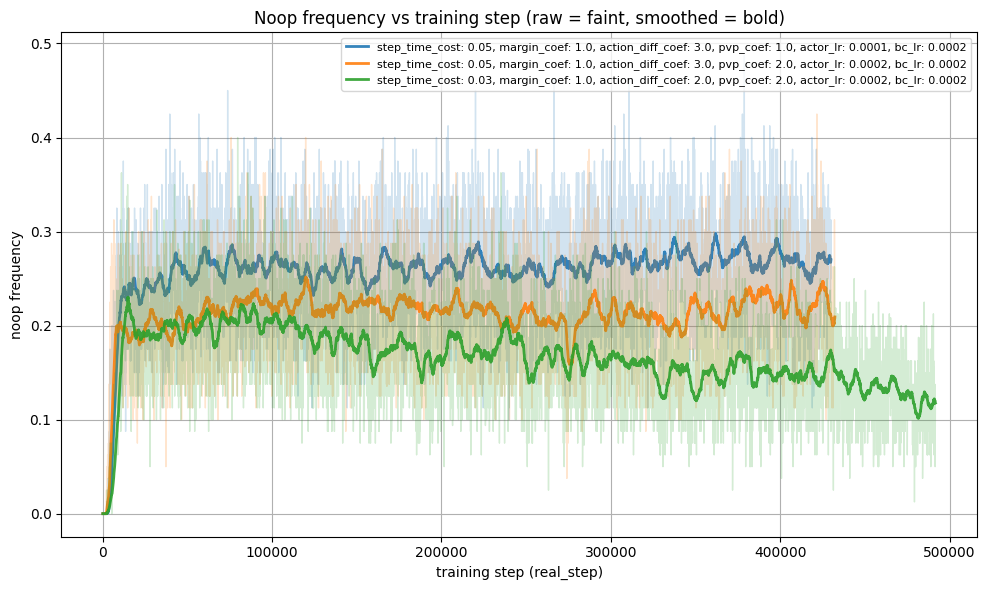

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if not run_logs:
    raise RuntimeError("run_logs is empty. Run the previous cell first.")

# ==== 설정 ====
max_step = 500_000        # 예: 3_000_000 처럼 최대 step 지정, 전체 사용하려면 None
smoothing_window = 50    # 이동평균 윈도우 길이 (step 개수 기준)
# ===============

plt.figure(figsize=(10, 6))

for idx, (run_name, df) in enumerate(run_logs.items()):
    cfg = run_configs.get(run_name, {})

    step_time_cost   = cfg.get("step_time_cost", None)
    margin_coef      = cfg.get("icopro_margin_coef", None)
    action_diff_coef = cfg.get("icopro_action_diff_coef", None)
    pvp_coef         = cfg.get("icopro_pvp_coef", None)
    actor_lr         = cfg.get("actor_learning_rate", None)
    bc_lr            = cfg.get("icopro_actor_lr", None)  # bc learning rate

    if "real_step" not in df.columns or "noop_frequency" not in df.columns:
        print(f"[skip] {run_name}: missing 'real_step' or 'noop_frequency' columns")
        continue

    x = df["real_step"].to_numpy()
    y = df["noop_frequency"].to_numpy()
    mask = np.isfinite(x) & np.isfinite(y)
    if max_step is not None:
        mask &= (x <= max_step)
    x, y = x[mask], y[mask]

    if x.size == 0:
        print(f"[skip] {run_name}: empty after filtering")
        continue

    # smoothing (moving average)
    y_smooth = pd.Series(y).rolling(
        window=max(1, smoothing_window),
        min_periods=1
    ).mean().to_numpy()

    color = plt.cm.tab10(idx % 10)

    # 원래 값: 희미하게 표시
    plt.plot(x, y, color=color, alpha=0.2, linewidth=1)

    # smoothed 값: 진하게, legend용
    label = (
        f"step_time_cost: {step_time_cost}, "
        f"margin_coef: {margin_coef}, "
        f"action_diff_coef: {action_diff_coef}, "
        f"pvp_coef: {pvp_coef}, "
        f"actor_lr: {actor_lr}, "
        f"bc_lr: {bc_lr}"
    )
    plt.plot(x, y_smooth, color=color, alpha=0.9, linewidth=2, label=label)

plt.xlabel("training step (real_step)")
plt.ylabel("noop frequency")
plt.title("Noop frequency vs training step (raw = faint, smoothed = bold)")
plt.legend(loc="best", fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()


# rmean_episode_return

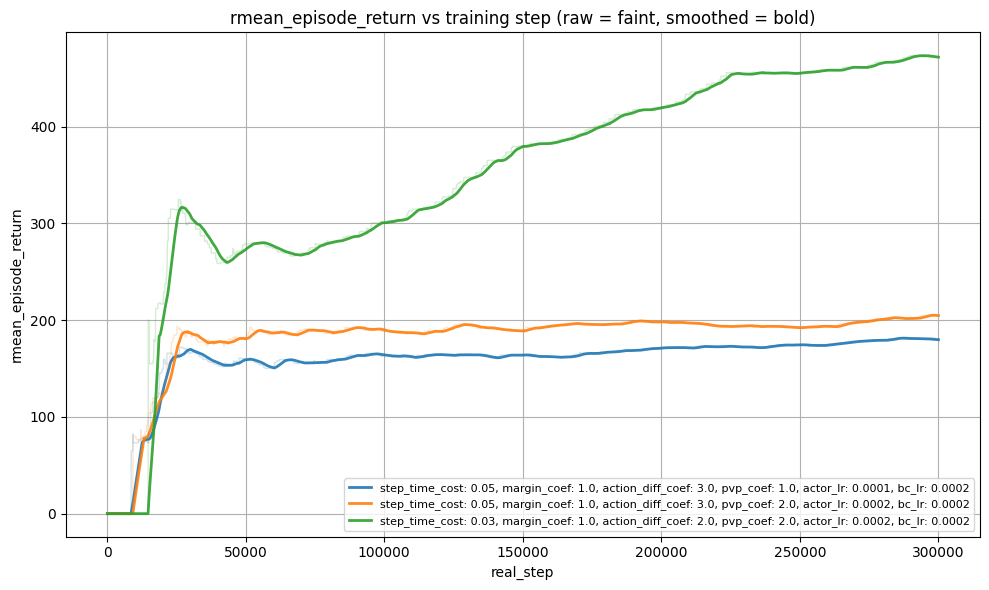

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if not run_logs:
    raise RuntimeError("run_logs is empty. Run the previous cell first.")

# ==== 설정 ====
max_step = 300_000       # 전체 사용하려면 None
smoothing_window = 50   # 이동평균 윈도우 길이
# ===============

plt.figure(figsize=(10, 6))

for idx, (run_name, df) in enumerate(run_logs.items()):
    cfg = run_configs.get(run_name, {})

    step_time_cost   = cfg.get("step_time_cost", None)
    margin_coef      = cfg.get("icopro_margin_coef", None)
    action_diff_coef = cfg.get("icopro_action_diff_coef", None)
    pvp_coef         = cfg.get("icopro_pvp_coef", None)
    actor_lr         = cfg.get("actor_learning_rate", None)
    bc_lr            = cfg.get("icopro_actor_lr", None)

    # x축: real_step 우선, 없으면 step
    x_col = "real_step" if "real_step" in df.columns else "step"

    if x_col not in df.columns or "rmean_episode_return" not in df.columns:
        print(f"[skip] {run_name}: missing '{x_col}' or 'rmean_episode_return' columns")
        continue

    x = df[x_col].to_numpy()
    y = df["rmean_episode_return"].to_numpy()
    mask = np.isfinite(x) & np.isfinite(y)
    if max_step is not None:
        mask &= (x <= max_step)
    x, y = x[mask], y[mask]

    if x.size == 0:
        print(f"[skip] {run_name}: empty after filtering")
        continue

    # smoothing (moving average)
    y_smooth = pd.Series(y).rolling(
        window=max(1, smoothing_window),
        min_periods=1
    ).mean().to_numpy()

    color = plt.cm.tab10(idx % 10)

    # 원래 값: 희미하게 표시
    plt.plot(x, y, color=color, alpha=0.2, linewidth=1)

    # smoothed 값: 진하게, legend용
    label = (
        f"step_time_cost: {step_time_cost}, "
        f"margin_coef: {margin_coef}, "
        f"action_diff_coef: {action_diff_coef}, "
        f"pvp_coef: {pvp_coef}, "
        f"actor_lr: {actor_lr}, "
        f"bc_lr: {bc_lr}"
    )
    plt.plot(x, y_smooth, color=color, alpha=0.9, linewidth=2, label=label)

plt.xlabel(x_col)
plt.ylabel("rmean_episode_return")
plt.title("rmean_episode_return vs training step (raw = faint, smoothed = bold)")
plt.legend(loc="best", fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()


# Human action prediction accuracy

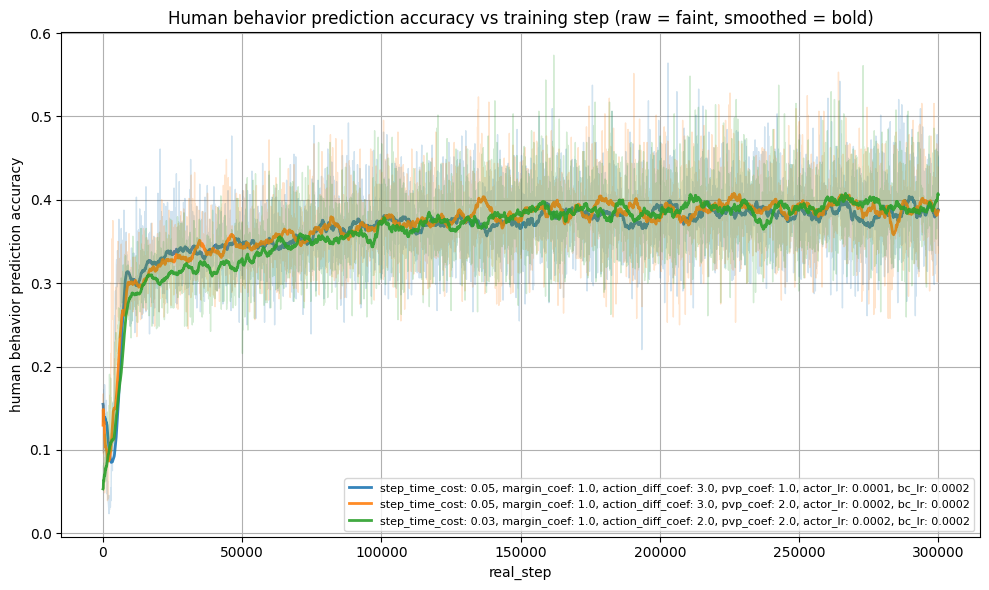

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if not run_logs:
    raise RuntimeError("run_logs is empty. Run the previous cell first.")

# ==== 설정 ====
max_step = 300_000       # 전체 사용하려면 None
smoothing_window = 50   # 이동평균 윈도우 길이
# ===============

plt.figure(figsize=(10, 6))

for idx, (run_name, df) in enumerate(run_logs.items()):
    cfg = run_configs.get(run_name, {})

    step_time_cost   = cfg.get("step_time_cost", None)
    margin_coef      = cfg.get("icopro_margin_coef", None)
    action_diff_coef = cfg.get("icopro_action_diff_coef", None)
    pvp_coef         = cfg.get("icopro_pvp_coef", None)
    actor_lr         = cfg.get("actor_learning_rate", None)
    bc_lr            = cfg.get("icopro_actor_lr", None)

    # x축: real_step 우선, 없으면 step
    x_col = "real_step" if "real_step" in df.columns else "step"
    y_col = "icopro/actor/accuracy"  # human behavior prediction accuracy

    if x_col not in df.columns or y_col not in df.columns:
        print(f"[skip] {run_name}: missing '{x_col}' or '{y_col}' columns")
        continue

    x = df[x_col].to_numpy()
    y = df[y_col].to_numpy()
    mask = np.isfinite(x) & np.isfinite(y)
    if max_step is not None:
        mask &= (x <= max_step)
    x, y = x[mask], y[mask]

    if x.size == 0:
        print(f"[skip] {run_name}: empty after filtering")
        continue

    # smoothing (moving average)
    y_smooth = pd.Series(y).rolling(
        window=max(1, smoothing_window),
        min_periods=1
    ).mean().to_numpy()

    color = plt.cm.tab10(idx % 10)

    # 원래 값: 희미하게 표시
    plt.plot(x, y, color=color, alpha=0.2, linewidth=1)

    # smoothed 값: 진하게, legend용
    label = (
        f"step_time_cost: {step_time_cost}, "
        f"margin_coef: {margin_coef}, "
        f"action_diff_coef: {action_diff_coef}, "
        f"pvp_coef: {pvp_coef}, "
        f"actor_lr: {actor_lr}, "
        f"bc_lr: {bc_lr}"
    )
    plt.plot(x, y_smooth, color=color, alpha=0.9, linewidth=2, label=label)

plt.xlabel(x_col)
plt.ylabel("human behavior prediction accuracy")
plt.title("Human behavior prediction accuracy vs training step (raw = faint, smoothed = bold)")
plt.legend(loc="best", fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()


### action_seq 분석

In [ ]:
import numpy as np
from pathlib import Path
import random
from scipy import stats

# ==== 사용자 설정 ====
# 연속 시퀀스 길이 (L)
SEQ_LEN = 30
# 불러올 시퀀스 개수
NUM_SEQS = 100

# 인간 행동 데이터 (IcoPro behavioral_data_block) 설정
HUMAN_BASE_DIR = Path.home() / "thinker" / "behavioral_data_block"
HUMAN_SUBJECT = 1   # 예: sub_1
HUMAN_GAME_ID = 2   # 예: game_2 (Space Invaders)

# Thinker baseline 행동 데이터 (여러 폴더 지정 가능)
THINKER_BASE_DIRS = [
    #Path("test/thinker-20250806-002733-4000032-0"),
    Path('test/example')
    # 필요시 다른 폴더 추가
    # Path("test/thinker-20251130-155103-195600-0"),
]

# Imitation 에이전트 행동 데이터 (여러 폴더 지정 가능)
IMIT_DIRS = [
    Path("test/thinker-20251219-100100-2603248-0/"),
    # 필요시 다른 폴더 추가
]

# 코사인 유사도 샘플링 개수 (각 비교당 최대 페어 수)
NUM_PAIRS = 1000

RNG_SEED = 0
rng = np.random.default_rng(RNG_SEED)
random.seed(RNG_SEED)


In [6]:
import numpy as np
from pathlib import Path

# 전역 RNG (이미 있다면 이 줄은 생략 가능)
RNG_SEED = 0
rng = np.random.default_rng(RNG_SEED)

def _argmax_actions(actions: np.ndarray) -> np.ndarray:
    """action 배열을 index 시퀀스로 변환."""
    actions = np.asarray(actions)
    if actions.ndim == 1:
        return actions.astype(int)
    if actions.ndim == 2:
        return actions.argmax(axis=-1)
    raise ValueError(f"Unsupported action array shape {actions.shape}")


def _normalize_rows(X: np.ndarray) -> np.ndarray:
    """행 단위 L2 정규화."""
    X = np.asarray(X, dtype=np.float32)
    norm = np.linalg.norm(X, axis=1, keepdims=True)
    norm[norm == 0] = 1.0
    return X / norm


def sample_human_action_sequences(
    seq_len: int,
    num_seqs: int,
    subject: int,
    game_id: int,
    base_dir: Path,
):
    """
    ~/thinker/behavioral_data_block/sub_{subject}/game_{game_id} 이하에서
    연속 길이 seq_len의 action 시퀀스를 num_seqs개 랜덤 샘플.
    각 시퀀스는 one-hot 후 flatten된 벡터로 반환.
    """
    root = base_dir / f"sub_{subject}" / f"game_{game_id}"
    if not root.exists():
        raise FileNotFoundError(f"Human data root not found: {root}")

    npz_paths = sorted(root.rglob("*.npz"))
    if not npz_paths:
        raise FileNotFoundError(f"No .npz files under {root}")

    # 파일별 action 시퀀스 및 후보 구간 수집
    human_actions_list = []
    candidates = []  # (file_idx, start_idx)
    num_actions = None

    for file_idx, path in enumerate(npz_paths):
        try:
            with np.load(path, allow_pickle=True) as data:
                actions_raw = data["action"]
        except Exception as e:
            print(f"[skip human] {path}: {e}")
            continue

        actions_raw = np.asarray(actions_raw)
        if num_actions is None:
            if actions_raw.ndim == 1:
                num_actions = int(actions_raw.max()) + 1
            elif actions_raw.ndim == 2:
                num_actions = actions_raw.shape[-1]
            else:
                raise ValueError(f"Unexpected action shape in {path}: {actions_raw.shape}")

        actions_idx = _argmax_actions(actions_raw)
        T = len(actions_idx)
        if T < seq_len:
            continue

        human_actions_list.append(actions_idx)
        local_file_idx = len(human_actions_list) - 1
        for start in range(0, T - seq_len + 1):
            candidates.append((local_file_idx, start))

    if not candidates:
        raise RuntimeError("No valid human sequences of given length.")

    if num_seqs > len(candidates):
        print(f"[human] Requested {num_seqs} sequences, but only {len(candidates)} available; using all.")
        num_seqs = len(candidates)

    sampled = rng.choice(len(candidates), size=num_seqs, replace=False)
    vectors = []

    eye = np.eye(num_actions, dtype=np.float32)

    for idx in sampled:
        file_idx, start = candidates[idx]
        actions_idx = human_actions_list[file_idx][start:start + seq_len]
        one_hot = eye[actions_idx]              # (L, A)
        vec = one_hot.reshape(-1)               # (L * A,)
        vectors.append(vec)

    human_vectors = np.stack(vectors, axis=0)   # (N, L * A)
    return human_vectors, num_actions


def sample_thinker_action_sequences(
    seq_len: int,
    num_seqs: int,
    thinker_dirs: list,
    num_actions_required: int = None,
):
    """
    지정한 폴더들에서 .npy를 찾아
    data['status'] == 0 인 step들만 시간 순서대로 이어 붙인 뒤,
    그 압축된 real-step 시퀀스에서 길이 seq_len의 연속 시퀀스를 num_seqs개 샘플.

    각 시퀀스는 one-hot(이미 one-hot일 경우 그대로) 후 flatten된 벡터로 반환.
    """
    all_candidates = []  # (actions_onehot_array, start_idx_in_compressed)
    detected_num_actions = None

    for base_dir in thinker_dirs:
        base_dir = Path(base_dir)
        if not base_dir.exists():
            print(f"[warn thinker] base dir does not exist: {base_dir}")
            continue

        for npy_path in sorted(base_dir.glob("*.npy")):
            try:
                data = np.load(npy_path, allow_pickle=True).item()
            except Exception as e:
                print(f"[skip thinker] {npy_path}: {e}")
                continue

            if "status" not in data:
                continue
            status = np.asarray(data["status"])

            tree_reps = data.get("tree_reps", {})
            if "root_action" not in tree_reps:
                continue
            root_action = np.asarray(tree_reps["root_action"])
            if root_action.ndim != 2:
                print(f"[skip thinker] unexpected root_action shape {root_action.shape} in {npy_path}")
                continue

            T, A = root_action.shape
            if detected_num_actions is None:
                detected_num_actions = A
            elif detected_num_actions != A:
                print(f"[warn] inconsistent num_actions in {npy_path}: {A} vs {detected_num_actions}; skipping file.")
                continue

            if T != len(status):
                print(f"[skip thinker] length mismatch in {npy_path}: status {len(status)}, root_action {T}")
                continue

            # status == 0인 step들만 시간 순으로 압축
            real_mask = (status == 0)
            if not np.any(real_mask):
                continue
            real_actions = root_action[real_mask]  # (T_real, A)
            T_real = len(real_actions)
            if T_real < seq_len:
                continue

            # 압축된 real-step 시퀀스에서 sliding window
            for start in range(0, T_real - seq_len + 1):
                all_candidates.append((real_actions, start))

    if not all_candidates:
        raise RuntimeError("No valid thinker sequences of given length from status==0 steps.")

    if num_seqs > len(all_candidates):
        print(f"[thinker] Requested {num_seqs} sequences, but only {len(all_candidates)} available; using all.")
        num_seqs = len(all_candidates)

    sampled_indices = rng.choice(len(all_candidates), size=num_seqs, replace=False)
    vectors = []

    for idx in sampled_indices:
        actions_onehot, start = all_candidates[idx]
        seq = actions_onehot[start:start + seq_len]  # (L, A)
        vec = seq.reshape(-1)                       # (L * A,)
        vectors.append(vec)

    thinker_vectors = np.stack(vectors, axis=0)     # (N, L * A)

    if num_actions_required is not None and detected_num_actions is not None:
        if detected_num_actions != num_actions_required:
            raise ValueError(
                f"num_actions mismatch: human={num_actions_required}, thinker={detected_num_actions}"
            )

    return thinker_vectors, detected_num_actions


[human] vectors shape: (50, 300), num_actions=6
[thinker] vectors shape: (50, 300), num_actions=6
[imit] vectors shape: (50, 300), num_actions=6
=== Cosine similarity (human vs Thinker / Imit) ===
human vs Thinker: mean = 0.1312, std = 0.0734
human vs Imit   : mean = 0.1708, std = 0.0551
=== Cosine similarity (random vs Thinker / Imit) ===
random vs Thinker: mean = 0.1748, std = 0.0464
random vs Imit   : mean = 0.1708, std = 0.0485


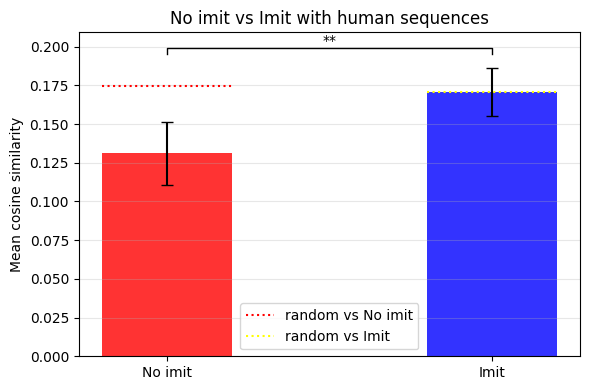

In [7]:
import matplotlib.pyplot as plt
from scipy import stats

# 1) 인간 행동 시퀀스 불러오기
human_vectors, human_num_actions = sample_human_action_sequences(
    seq_len=SEQ_LEN,
    num_seqs=NUM_SEQS,
    subject=HUMAN_SUBJECT,
    game_id=HUMAN_GAME_ID,
    base_dir=HUMAN_BASE_DIR,
)
print(f"[human] vectors shape: {human_vectors.shape}, num_actions={human_num_actions}")

# 2) Thinker baseline 행동 시퀀스 불러오기
thinker_vectors, thinker_num_actions = sample_thinker_action_sequences(
    seq_len=SEQ_LEN,
    num_seqs=NUM_SEQS,
    thinker_dirs=THINKER_BASE_DIRS,
    num_actions_required=human_num_actions,
)
print(f"[thinker] vectors shape: {thinker_vectors.shape}, num_actions={thinker_num_actions}")

# 3) Imitation 에이전트 행동 시퀀스 불러오기
imit_vectors, imit_num_actions = sample_thinker_action_sequences(
    seq_len=SEQ_LEN,
    num_seqs=NUM_SEQS,
    thinker_dirs=IMIT_DIRS,
    num_actions_required=human_num_actions,
)
print(f"[imit] vectors shape: {imit_vectors.shape}, num_actions={imit_num_actions}")

# 4) L2 정규화
human_norm   = _normalize_rows(human_vectors)
thinker_norm = _normalize_rows(thinker_vectors)
imit_norm    = _normalize_rows(imit_vectors)

# 5) 코사인 유사도 샘플링 (인간 vs 각 에이전트)
max_pairs = min(len(human_norm), len(thinker_norm), len(imit_norm), NUM_PAIRS)
if max_pairs < 2:
    raise RuntimeError(f"Not enough sequences for similarity comparison (pairs={max_pairs}).")

idx_h = rng.integers(0, len(human_norm),   size=max_pairs)
idx_t = rng.integers(0, len(thinker_norm), size=max_pairs)
idx_i = rng.integers(0, len(imit_norm),    size=max_pairs)

cos_ht = np.einsum("ij,ij->i", human_norm[idx_h], thinker_norm[idx_t])  # human vs thinker
cos_hi = np.einsum("ij,ij->i", human_norm[idx_h], imit_norm[idx_i])     # human vs imit

# 6) 랜덤 시퀀스 생성 후 각 에이전트와 비교 (baseline)
rand_actions_t = rng.integers(0, thinker_num_actions, size=(max_pairs, SEQ_LEN))
rand_onehot_t  = np.eye(thinker_num_actions, dtype=np.float32)[rand_actions_t]
rand_vectors_t = rand_onehot_t.reshape(max_pairs, -1)
rand_norm_t    = _normalize_rows(rand_vectors_t)
cos_tr = np.einsum("ij,ij->i", thinker_norm[idx_t], rand_norm_t)        # thinker vs random

rand_actions_i = rng.integers(0, imit_num_actions, size=(max_pairs, SEQ_LEN))
rand_onehot_i  = np.eye(imit_num_actions, dtype=np.float32)[rand_actions_i]
rand_vectors_i = rand_onehot_i.reshape(max_pairs, -1)
rand_norm_i    = _normalize_rows(rand_vectors_i)
cos_ir = np.einsum("ij,ij->i", imit_norm[idx_i], rand_norm_i)           # imit vs random

# 7) 요약 통계 출력
def summary(name, x):
    print(f"{name}: mean = {x.mean():.4f}, std = {x.std(ddof=1):.4f}")

print("=== Cosine similarity (human vs Thinker / Imit) ===")
summary("human vs Thinker", cos_ht)
summary("human vs Imit   ", cos_hi)

print("=== Cosine similarity (random vs Thinker / Imit) ===")
summary("random vs Thinker", cos_tr)
summary("random vs Imit   ", cos_ir)

# 8) 바 플롯 + 유의성 (*) 표시 (random은 점선만)
def mean_ci_95(x):
    x = np.asarray(x, dtype=float)
    if x.size <= 1:
        return x.mean(), 0.0
    m = x.mean()
    e = stats.sem(x) * 1.96  # 95% CI
    return m, e

m_ht, ci_ht = mean_ci_95(cos_ht)
m_hi, ci_hi = mean_ci_95(cos_hi)
m_tr, ci_tr = mean_ci_95(cos_tr)
m_ir, ci_ir = mean_ci_95(cos_ir)

labels = ["No imit", "Imit"]
x = np.arange(len(labels))
bar_width = 0.4
colors = ["red", "blue"]

fig, ax = plt.subplots(figsize=(6, 4))

means = [m_ht, m_hi]
cis   = [ci_ht, ci_hi]
bars = ax.bar(x, means, yerr=cis, color=colors, alpha=0.8, capsize=4, width=bar_width)

# 유의성(*) 표시 함수
def add_sig(ax, x1, x2, y, p):
    if p < 0.001:
        mark = "***"
    elif p < 0.01:
        mark = "**"
    elif p < 0.05:
        mark = "*"
    else:
        mark = "ns"
    h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color="black", lw=1)
    ax.text((x1 + x2) / 2, y + h, mark, ha="center", va="bottom")

# Human 기반 Thinker vs Imit 비교
t_stat_h, p_val_h = stats.ttest_ind(cos_ht, cos_hi, equal_var=False)
y_h = max(bars[0].get_height() + cis[0], bars[1].get_height() + cis[1]) * 1.05
add_sig(ax, x[0], x[1], y_h, p_val_h)

# Random baseline: 각 bar에 해당하는 점선
# Thinker random baseline (빨간 점선)
ax.hlines(
    y=m_tr,
    xmin=x[0] - bar_width/2,
    xmax=x[0] + bar_width/2,
    colors="red",
    linestyles=":",
    label="random vs No imit",
)

# Imit random baseline (파란 점선)
ax.hlines(
    y=m_ir,
    xmin=x[1] - bar_width/2,
    xmax=x[1] + bar_width/2,
    colors="yellow",
    linestyles=":",
    label="random vs Imit",
)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Mean cosine similarity")
ax.set_title("No imit vs Imit with human sequences")
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="best")

plt.tight_layout()
plt.show()
